# SBA 504 Lending Analysis  
**Author:** Mohamed Noor Hussein  
**Date:** May 1 2025  
**Purpose:** Build panel regressions and XGBoost/SHAP explainability on county‐level SBA data.  



# SBA 504 Loan Correlation Analysis (Comprehensive Notebook)

This notebook contains the complete Python code for the SBA 504 loan correlation analysis project, including data preparation, exploratory data analysis (correlation, summary statistics), visualizations, panel regression, and XGBoost/SHAP analysis.

**Assumptions:**
- The necessary input data files (from `sba_github_data.zip`) are located in a `data/` subdirectory relative to this notebook (e.g., `data/processed/`, `data/lookups/`).
- All required libraries are installed (see the first code cell).

## 1. Initial Setup and Library Installation

In [1]:
# --- Cell ID: HwrfQfeMV3Pj (from revised notebook) ---
!pip install linearmodels xgboost shap pandas numpy matplotlib seaborn statsmodels openpyxl nbformat joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 1.6 MB/s eta 0:00:00


## 2. Imports, Configuration, and Initial Data Loading

In [46]:
# 1. Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 2. File paths
BASE     = "/content"
SBA_FILE = os.path.join(BASE, "sba_504_raw_concatenated.parquet")
...


Ellipsis

In [48]:
# 1. Load & normalize ACS
income = pd.read_parquet("/content/acs_s1901_income_processed.parquet")\
           .rename(columns={"Year":"year","MedianHouseholdIncome":"median_household_income"})
poverty = pd.read_parquet("/content/acs_b17001_poverty_processed.parquet")\
            .rename(columns={"Year":"year","PovertyRate":"poverty_rate"})
population = pd.read_parquet("/content/acs_dp05_population_processed.parquet")\
               .rename(columns={"Year":"year","TotalPopulation":"total_population"})

acs_merged = (income
              .merge(poverty, on=["fips","year"], how="outer")
              .merge(population, on=["fips","year"], how="outer"))

# 2. Deflate income
cpi = pd.read_csv("/content/cpi_u_annual_avg_2010_2023.csv")\
        .rename(columns={"Year":"year","CPI_U_Annual_Avg":"cpi"})
base = cpi.loc[cpi.year==2023,"cpi"].iloc[0]
cpi["deflator"] = base/cpi["cpi"]
acs_merged["income_adjusted"] = (
    acs_merged["median_household_income"] *
    acs_merged.merge(cpi[["year","deflator"]],on="year",how="left")["deflator"]
)

acs_merged.to_parquet("/content/merged_acs_data.parquet", index=False)

# 3. Load SBA + lookup → fips
sba = pd.read_parquet("/content/sba_504_raw_concatenated.parquet")
sba["ProjectCounty"] = sba.ProjectCounty.str.upper().str.strip() + " COUNTY"
sba["ProjectState"]  = sba.ProjectState.str.upper().str.strip()
lookup = pd.read_csv("/content/fips_lookup.csv",dtype=str)
lookup["name"]  = lookup.name.str.upper().str.strip()
lookup["state"] = lookup.state.str.upper().str.strip()

sba = sba.merge(
    lookup[["fips","name","state"]],
    left_on=["ProjectCounty","ProjectState"],
    right_on=["name","state"],
    how="left"
)

# 4. Aggregate & join
sba = sba.rename(columns={"Year":"year"})
summary = (sba.groupby(["fips","year"])
            .agg(LoanAmount=("GrossApproval","sum"),
                 LoanCount=("GrossApproval","count"))
            .reset_index())

panel = summary.merge(acs_merged, on=["fips","year"], how="left")
panel["LoanAmountPerCapita"] = panel.LoanAmount / panel.total_population

# 5. Save final enhanced panel
panel.to_parquet("/content/enhanced_panel_data.parquet", index=False)
print("✅ enhanced_panel_data.parquet created:", panel.shape)


✅ enhanced_panel_data.parquet created: (2270, 9)


In [49]:
import pandas as pd
import numpy as np
import os
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# --- Configuration ---
BASE_DIR = "/content"

# Uploaded file paths (in flat Colab directory)
FIPS_LOOKUP_FILE  = os.path.join(BASE_DIR, "fips_lookup.csv")
SBA_504_FILE      = os.path.join(BASE_DIR, "sba_504_raw_concatenated.parquet")
MERGED_ACS_FILE   = os.path.join(BASE_DIR, "merged_acs_data.parquet")
CPI_FILE          = os.path.join(BASE_DIR, "cpi_u_annual_avg_2010_2023.csv")

# Output file paths
RESULTS_DIR                = os.path.join(BASE_DIR, "results")
CORRELATION_RESULTS_DIR    = os.path.join(RESULTS_DIR, "correlation_analysis")
PANEL_RESULTS_DIR          = os.path.join(RESULTS_DIR, "panel_regression")
XGBOOST_RESULTS_DIR        = os.path.join(RESULTS_DIR, "xgboost_shap")

ENHANCED_PANEL_FILE        = os.path.join(BASE_DIR, "enhanced_panel_data.parquet")
REG_OUT                    = os.path.join(PANEL_RESULTS_DIR, "panel_regression_results.txt")
VIF_OUT                    = os.path.join(PANEL_RESULTS_DIR, "vif_results.txt")
MODEL_PATH                 = os.path.join(XGBOOST_RESULTS_DIR, "xgboost_model.joblib")
METRICS_TXT                = os.path.join(XGBOOST_RESULTS_DIR, "xgboost_metrics.txt")
SHAP_PNG                   = os.path.join(XGBOOST_RESULTS_DIR, "shap_summary.png")

# Ensure output folders exist
for _dir in [RESULTS_DIR, CORRELATION_RESULTS_DIR, PANEL_RESULTS_DIR, XGBOOST_RESULTS_DIR]:
    os.makedirs(_dir, exist_ok=True)

# Visualization settings
sns.set(style="whitegrid")

# --- Load Initial Data ---
logging.info("Loading initial data files for preparation...")
sba_df = None
fips_lookup_df = None
merged_acs_df = None

try:
    sba_df = pd.read_parquet(SBA_504_FILE)
    logging.info(f"Loaded SBA 504 data. Shape: {sba_df.shape}")
except Exception as e:
    logging.error(f"Error loading SBA 504 data from {SBA_504_FILE}: {e}")

try:
    fips_lookup_df = pd.read_csv(FIPS_LOOKUP_FILE, dtype={"fips": str})
    fips_lookup_df["fips"] = fips_lookup_df["fips"].str.zfill(5)
    logging.info(f"Loaded FIPS lookup data. Shape: {fips_lookup_df.shape}")
except Exception as e:
    logging.error(f"Error loading FIPS lookup data from {FIPS_LOOKUP_FILE}: {e}")

try:
    merged_acs_df = pd.read_parquet(MERGED_ACS_FILE)
    logging.info(f"Loaded Merged ACS data. Shape: {merged_acs_df.shape}")
except Exception as e:
    logging.error(f"Error loading Merged ACS data from {MERGED_ACS_FILE}: {e}")


## 3. Data Preparation (Correlation Analysis Data)

In [50]:
import logging

# --- Clean county name for FIPS join ---
def clean_county_name(name):
    if pd.isna(name):
        return None
    name = str(name).lower()
    suffixes_to_remove = [
        " county", " parish", " city and borough", " borough",
        " census area", " municipality", " municipio", " city",
        " st.", " ste."
    ]
    for suffix in suffixes_to_remove:
        name = name.replace(suffix, "")
    chars_to_remove = [".", "\\", "'"]
    for char in chars_to_remove:
        name = name.replace(char, "")
    name = name.replace("saint ", "st ")
    return name.strip()

# --- Logging setup ---
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# --- Begin data prep ---
correlation_df = None
if sba_df is not None and fips_lookup is not None and acs_merged is not None:
    logging.info("Starting data preparation for correlation analysis...")

    # 1. Ensure date and year
    sba_df["ApprovalDate"] = pd.to_datetime(sba_df["ApprovalDate"], errors="coerce")
    sba_df["Year"] = sba_df["ApprovalDate"].dt.year
    sba_df_filtered = sba_df[sba_df["Year"].between(START_YEAR, END_YEAR)].copy()
    logging.info(f"Filtered SBA data ({START_YEAR}-{END_YEAR}): {len(sba_df_filtered)} loans")

    # 2. Clean county names for mapping
    sba_df_filtered["CleanCounty"] = sba_df_filtered["ProjectCounty"].apply(clean_county_name)
    fips_lookup["CleanCounty"] = fips_lookup["name"].apply(clean_county_name)

    # 3. Merge SBA + FIPS
    sba_with_fips = pd.merge(
        sba_df_filtered,
        fips_lookup[["state", "fips", "CleanCounty"]],
        left_on=["ProjectState", "CleanCounty"],
        right_on=["state", "CleanCounty"],
        how="left"
    )
    mapped_count = sba_with_fips["fips"].notna().sum()
    logging.info(f"Mapped {mapped_count} loans to FIPS codes. Dropping unmapped loans.")
    sba_with_fips = sba_with_fips.dropna(subset=["fips"])

    # 4. Aggregate lending intensity
    intensity_metrics = sba_with_fips.groupby(["Year", "fips"]).agg(
        TotalLoanAmountApproved=("GrossApproval", "sum"),
        NumberOfLoansApproved=("GrossApproval", "size")
    ).reset_index()

    # 5. Prepare ACS data types
    merged_acs_df = acs_merged.copy()
    merged_acs_df["Year"] = merged_acs_df["year"].astype("Int64")
    merged_acs_df["fips"] = merged_acs_df["fips"].astype(str)
    intensity_metrics["fips"] = intensity_metrics["fips"].astype(str)

    # 6. Merge intensity into ACS panel
    correlation_df = pd.merge(
        merged_acs_df,
        intensity_metrics,
        on=["Year", "fips"],
        how="left"
    )
    logging.info(f"Merged with ACS data. Shape: {correlation_df.shape}")

    # 7. Fill missing intensity data with 0
    for col in ["TotalLoanAmountApproved", "NumberOfLoansApproved"]:
        correlation_df[col] = correlation_df[col].fillna(0)

    # 8. Compute per capita metrics (init as float to avoid warning)
    correlation_df["LoanAmountPerCapita"] = 0.0
    correlation_df["LoansPer1000People"] = 0.0

    valid = correlation_df["total_population"].notna() & (correlation_df["total_population"] > 0)

    correlation_df.loc[valid, "LoanAmountPerCapita"] = (
        correlation_df.loc[valid, "TotalLoanAmountApproved"] / correlation_df.loc[valid, "total_population"]
    )
    correlation_df.loc[valid, "LoansPer1000People"] = (
        correlation_df.loc[valid, "NumberOfLoansApproved"] / correlation_df.loc[valid, "total_population"] * 1000
    )

    # 9. Save output
    correlation_df.to_parquet("/content/correlation_analysis_data.parquet", index=False)
    logging.info("✅ correlation_analysis_data.parquet saved.")

    # Show preview
    print("\nSample:")
    print(correlation_df.head())

else:
    logging.error("Missing one or more required dataframes. Aborting.")
    raise SystemExit("Data preparation failed.")



Sample:
   year   fips  median_household_income  poverty_rate  total_population  \
0  2010  01001                  19718.0           NaN               NaN   
1  2011  01001                  19998.0      0.108787           53944.0   
2  2012  01001                  19934.0      0.115510           54590.0   
3  2013  01001                  20071.0      0.121334           54907.0   
4  2014  01001                  20304.0      0.128052           55136.0   

   income_adjusted  Year  TotalLoanAmountApproved  NumberOfLoansApproved  \
0     27553.078273  2010                      0.0                    0.0   
1     27089.257959  2011                      0.0                    0.0   
2     26455.088844  2012                      0.0                    0.0   
3     26252.372077  2013                      0.0                    0.0   
4     26133.200730  2014                      0.0                    0.0   

   LoanAmountPerCapita  LoansPer1000People  
0                  0.0                

In [51]:
nonzero = correlation_df[correlation_df["TotalLoanAmountApproved"] > 0]
print(f"🟢 Non-zero loan rows: {len(nonzero)}")
nonzero[["year", "fips", "TotalLoanAmountApproved", "LoanAmountPerCapita"]].head()


🟢 Non-zero loan rows: 13545


,year,fips,TotalLoanAmountApproved,LoanAmountPerCapita
4430,2010,10001,362000.0,0.000000
4431,2011,10001,518000.0,3.238796
4432,2012,10001,1692000.0,10.394078
4433,2013,10001,908000.0,5.502030
4434,2014,10001,254000.0,1.516626


## 4. Data Enhancement (Inflation Adjustment)

In [52]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

logging.info("Starting data enhancement (inflation adjustment)...")

def load_data_enhance(path, description):
    try:
        logging.info(f"Loading {description} from {path}")
        if path.endswith(".csv"):
            df = pd.read_csv(path)
        elif path.endswith(".parquet"):
            df = pd.read_parquet(path)
        else:
            logging.error(f"Unsupported file type for {path}")
            return None
        logging.info(f"{description} loaded - shape {df.shape}")
        return df
    except FileNotFoundError:
        logging.error(f"{description} not found at {path}")
        return None
    except Exception as e:
        logging.error(f"Error reading {description}: {e}")
        return None

# Load data
CORRELATION_DATA_FILE = "/content/correlation_analysis_data.parquet"
CPI_FILE = "/content/cpi_u_annual_avg_2010_2023.csv"
ENHANCED_PANEL_FILE = "/content/enhanced_panel_data.parquet"
END_YEAR = 2023

df_corr = load_data_enhance(CORRELATION_DATA_FILE, "Correlation Data")
cpi_df = load_data_enhance(CPI_FILE, "CPI Data")

if df_corr is None or cpi_df is None:
    raise SystemExit("Required data for enhancement not loaded. Aborting.")

# Prepare CPI data
cpi_df["Year"] = pd.to_numeric(cpi_df["Year"], errors="coerce")
cpi_df = cpi_df.dropna(subset=["Year"])
cpi_df["Year"] = cpi_df["Year"].astype(int)

# Use correct CPI column name
if "AnnualAverage" not in cpi_df.columns:
    cpi_df.rename(columns={"CPI_U_Annual_Avg": "AnnualAverage"}, inplace=True)

cpi_base_value = cpi_df[cpi_df["Year"] == END_YEAR]["AnnualAverage"].iloc[0]
cpi_df["adjustment_factor"] = cpi_base_value / cpi_df["AnnualAverage"]
logging.info(f"CPI base year {END_YEAR} value: {cpi_base_value}")

# Merge CPI with correlation data
df_enhanced = pd.merge(df_corr, cpi_df[["Year", "adjustment_factor"]], on="Year", how="left")

# Adjust income
df_enhanced["income_adjusted"] = df_enhanced["median_household_income"] * df_enhanced["adjustment_factor"]
logging.info("Calculated inflation-adjusted income (income_adjusted).")

# Select final columns
final_cols = [
    "Year", "fips", "total_population", "median_household_income", "poverty_rate",
    "TotalLoanAmountApproved", "NumberOfLoansApproved",
    "LoanAmountPerCapita", "LoansPer1000People", "income_adjusted"
]

df_final_panel = df_enhanced[final_cols].copy()

# Save enhanced panel
try:
    df_final_panel.to_parquet(ENHANCED_PANEL_FILE, index=False)
    logging.info(f"Saved enhanced panel data to {ENHANCED_PANEL_FILE}. Shape: {df_final_panel.shape}")
    print("\n--- Enhanced Data Sample (Panel) ---")
    print(df_final_panel.head())
except Exception as e:
    logging.error(f"Error saving enhanced panel data: {e}")

print("Data enhancement finished.")

# Assign to df for modeling steps
df = df_final_panel



--- Enhanced Data Sample (Panel) ---
   Year   fips  total_population  median_household_income  poverty_rate  \
0  2010  01001               NaN                  19718.0           NaN   
1  2011  01001           53944.0                  19998.0      0.108787   
2  2012  01001           54590.0                  19934.0      0.115510   
3  2013  01001           54907.0                  20071.0      0.121334   
4  2014  01001           55136.0                  20304.0      0.128052   

   TotalLoanAmountApproved  NumberOfLoansApproved  LoanAmountPerCapita  \
0                      0.0                    0.0                  0.0   
1                      0.0                    0.0                  0.0   
2                      0.0                    0.0                  0.0   
3                      0.0                    0.0                  0.0   
4                      0.0                    0.0                  0.0   

   LoansPer1000People  income_adjusted  
0                 0.0    

## 5. Correlation Analysis and Table Generation

In [53]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Define file paths
CORRELATION_DATA_FILE = "/content/correlation_analysis_data.parquet"
SUMMARY_STATS_FILE = "/content/summary_statistics.csv"
CORRELATION_MATRIX_FILE = "/content/correlation_matrix.csv"
CORRELATION_CHANGES_MATRIX_FILE = "/content/correlation_changes_matrix.csv"

# --- Load prepared correlation data ---
logging.info(f"Loading prepared data from {CORRELATION_DATA_FILE} for correlation analysis...")
try:
    df_analysis = pd.read_parquet(CORRELATION_DATA_FILE)
    logging.info(f"Using data for correlation analysis. Shape: {df_analysis.shape}")
except Exception as e:
    logging.error(f"Error accessing correlation data: {e}")
    df_analysis = None

# --- Perform Analysis ---
if df_analysis is not None:
    logging.info("Starting correlation analysis...")

    # Define analysis variables
    intensity_vars = ["TotalLoanAmountApproved", "NumberOfLoansApproved", "LoanAmountPerCapita", "LoansPer1000People"]
    economic_vars = ["median_household_income", "poverty_rate"]
    control_vars = ["total_population"]
    analysis_vars = intensity_vars + economic_vars + control_vars

    # Clean any infinite values
    df_analysis[analysis_vars] = df_analysis[analysis_vars].replace([np.inf, -np.inf], np.nan)

    # --- 1. Descriptive Statistics ---
    try:
        summary_stats = df_analysis[analysis_vars].describe()
        print("\n--- Summary Statistics ---")
        print(summary_stats)
        summary_stats.to_csv(SUMMARY_STATS_FILE)
        logging.info(f"Saved summary statistics to {SUMMARY_STATS_FILE}")
    except Exception as e:
        logging.error(f"Error calculating/saving summary statistics: {e}")

    # --- 2. Correlation Matrix (Levels) ---
    try:
        df_corr = df_analysis[analysis_vars].dropna()
        logging.info(f"Shape after dropping NaNs for correlation: {df_corr.shape}")
        correlation_matrix = df_corr.corr()
        print("\n--- Correlation Matrix (Levels) ---")
        print(correlation_matrix)
        correlation_matrix.to_csv(CORRELATION_MATRIX_FILE)
        logging.info(f"Saved correlation matrix to {CORRELATION_MATRIX_FILE}")
    except Exception as e:
        logging.error(f"Error calculating/saving correlation matrix: {e}")

    # --- 3. Correlation Matrix (Year-over-Year Changes) ---
    try:
        df_sorted = df_analysis.sort_values(by=["fips", "Year"])
        df_diff = df_sorted.groupby("fips")[analysis_vars].diff()
        df_diff.columns = [f"{col}_diff" for col in analysis_vars]
        df_merged_diff = pd.concat([df_sorted[["Year", "fips"]], df_diff], axis=1).dropna()
        logging.info(f"Shape after calculating differences and dropping NaNs: {df_merged_diff.shape}")

        if not df_merged_diff.empty:
            correlation_changes_matrix = df_merged_diff.drop(columns=["Year", "fips"]).corr()
            print("\n--- Correlation Matrix (Year-over-Year Changes) ---")
            print(correlation_changes_matrix)
            correlation_changes_matrix.to_csv(CORRELATION_CHANGES_MATRIX_FILE)
            logging.info(f"Saved correlation matrix of changes to {CORRELATION_CHANGES_MATRIX_FILE}")
        else:
            logging.warning("No data available after calculating differences. Skipping correlation of changes.")

    except Exception as e:
        logging.error(f"Error calculating/saving correlation matrix of changes: {e}")

    logging.info("Correlation analysis finished.")
else:
    logging.error("Correlation dataframe not available. Skipping analysis.")

print("✅ Correlation analysis finished.")



--- Summary Statistics ---
       TotalLoanAmountApproved  NumberOfLoansApproved  LoanAmountPerCapita  \
count             4.512200e+04           45122.000000         45122.000000   
mean              1.223369e+06               1.632352             8.523887   
std               4.940763e+06               6.083683            32.614687   
min               0.000000e+00               0.000000             0.000000   
25%               0.000000e+00               0.000000             0.000000   
50%               0.000000e+00               0.000000             0.000000   
75%               3.320000e+05               1.000000             3.663791   
max               1.650590e+08             213.000000          1875.139353   

       LoansPer1000People  median_household_income  poverty_rate  \
count        45122.000000             4.508900e+04  41868.000000   
mean             0.013024             3.740785e+04      0.164015   
std              0.041324             1.137844e+05      0.081632 

## 6. Visualizations

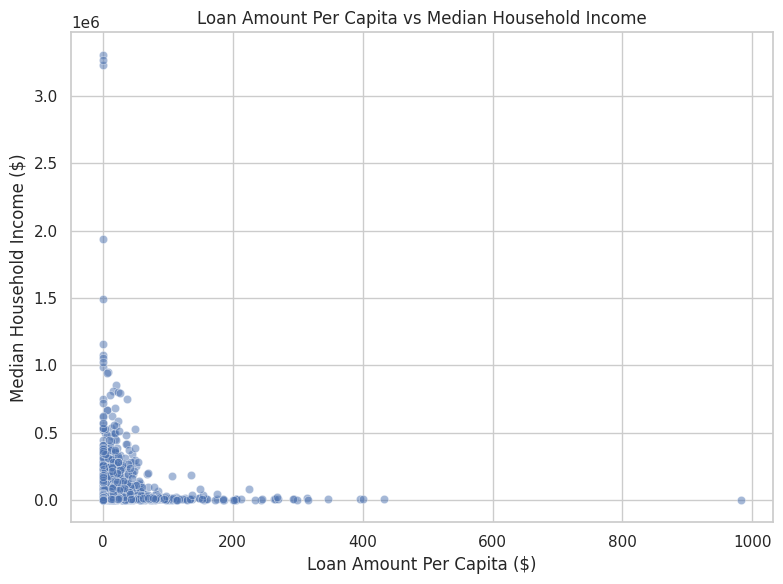

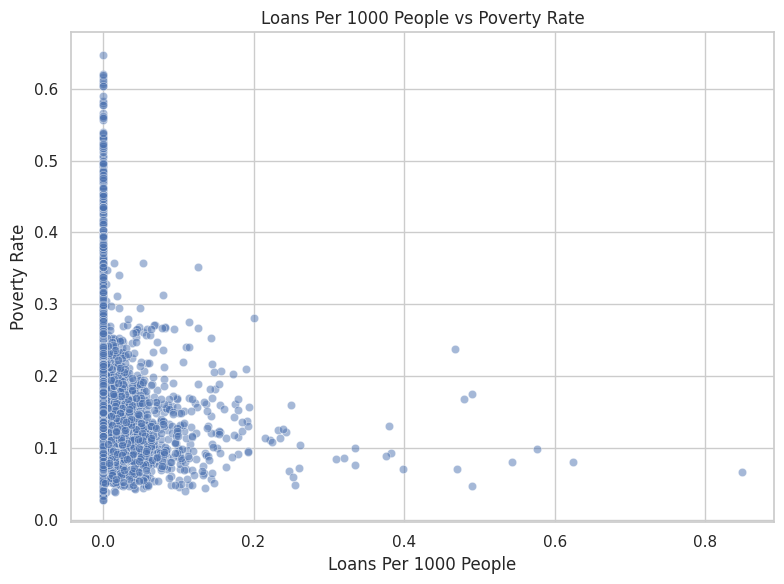

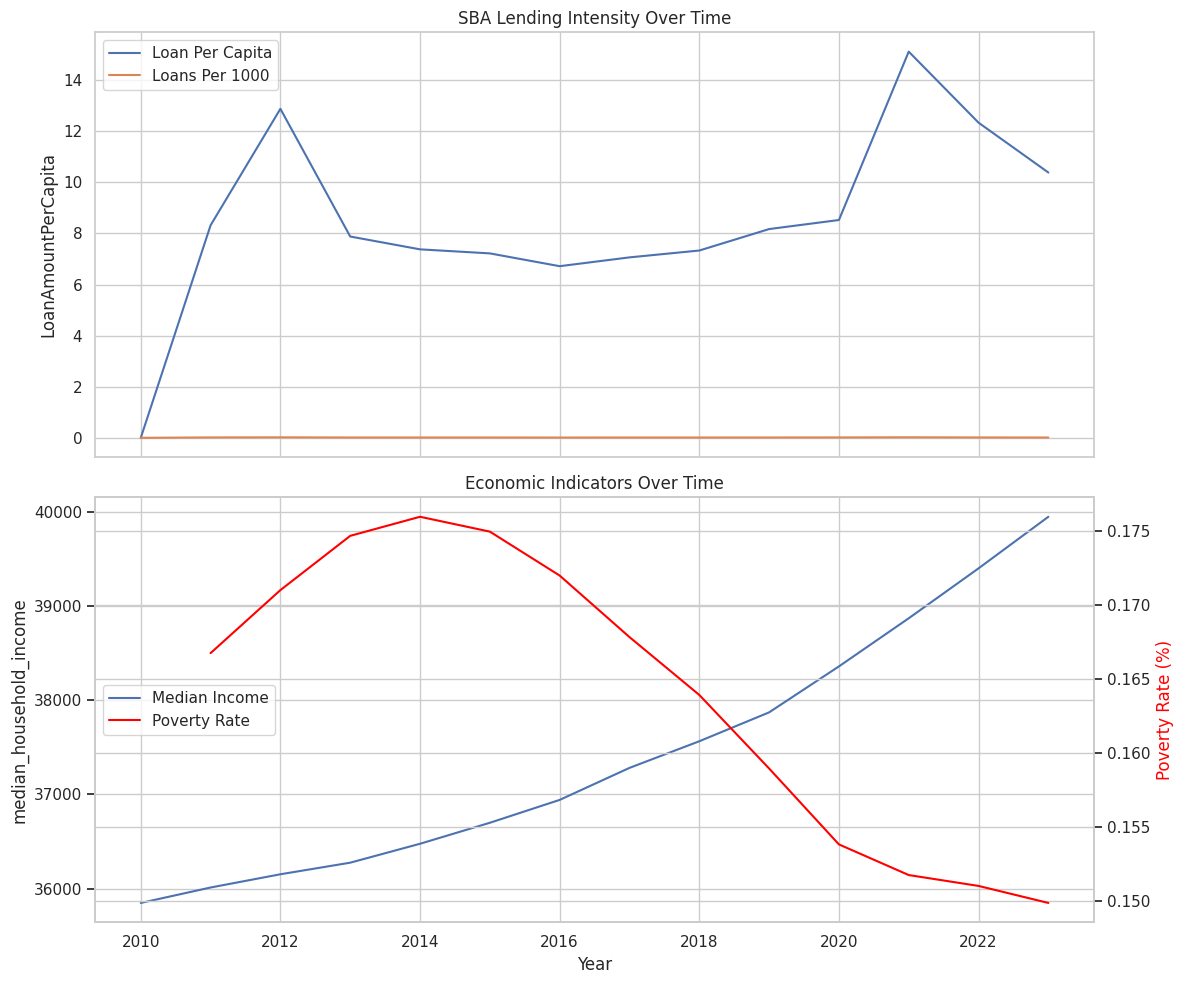

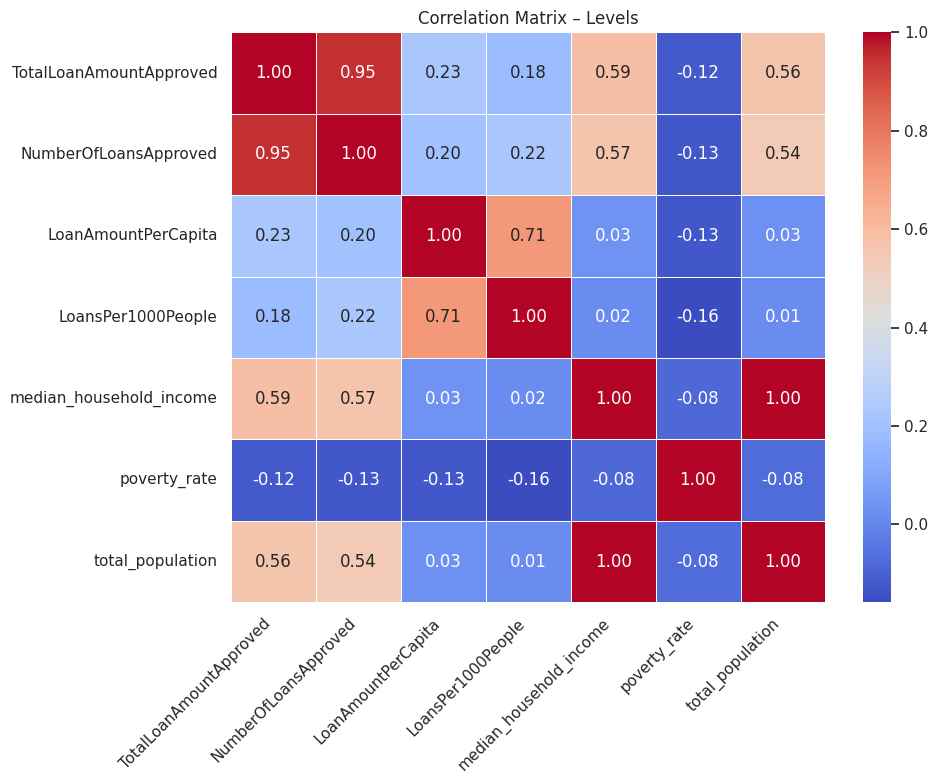

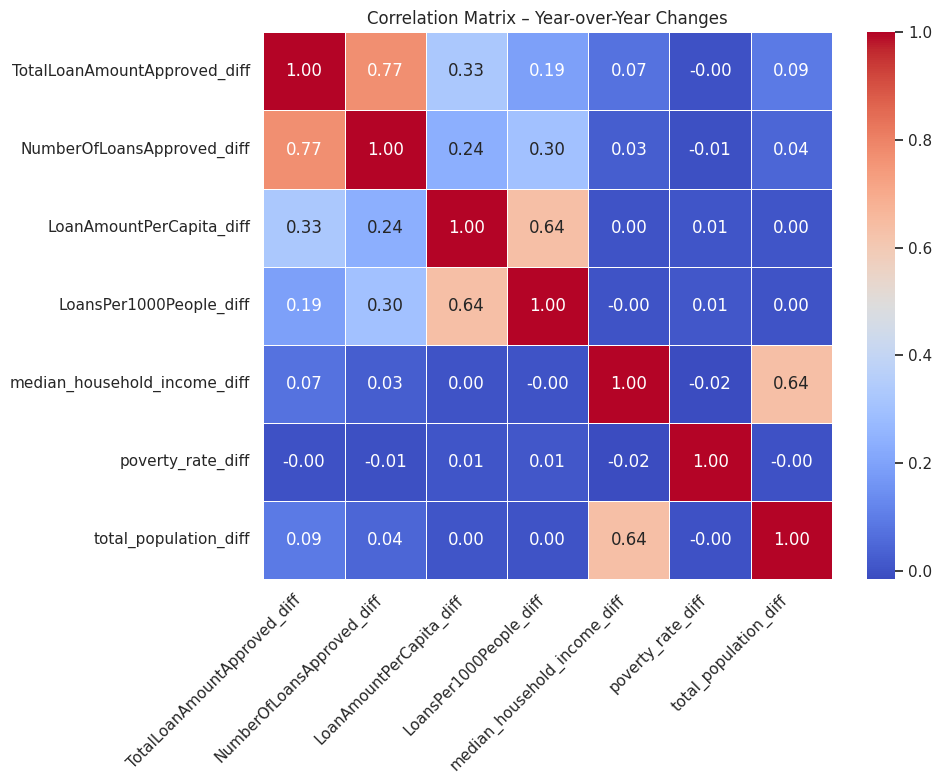

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure logging and directories
CORRELATION_RESULTS_DIR = "/content/results/correlation_analysis"
os.makedirs(CORRELATION_RESULTS_DIR, exist_ok=True)

if df_analysis is not None:
    logging.info("Creating visualizations...")

    # --- 1. Scatter Plots (Sampled) ---
    logging.info("Creating scatter plots (sample)...")
    df_sample = df_analysis.sample(n=min(5000, len(df_analysis)), random_state=42)

    # Scatter 1: LoanAmountPerCapita vs MedianHouseholdIncome
    try:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=df_sample, x="LoanAmountPerCapita", y="median_household_income", alpha=0.5)
        plt.title("Loan Amount Per Capita vs Median Household Income")
        plt.xlabel("Loan Amount Per Capita ($)")
        plt.ylabel("Median Household Income ($)")
        plt.tight_layout()
        plt.savefig(os.path.join(CORRELATION_RESULTS_DIR, "scatter_loan_per_capita_vs_income.png"))
        plt.show()
    except Exception as e:
        logging.error(f"Error creating scatter plot (Loan vs Income): {e}")

    # Scatter 2: LoansPer1000People vs PovertyRate
    try:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=df_sample, x="LoansPer1000People", y="poverty_rate", alpha=0.5)
        plt.title("Loans Per 1000 People vs Poverty Rate")
        plt.xlabel("Loans Per 1000 People")
        plt.ylabel("Poverty Rate")
        plt.tight_layout()
        plt.savefig(os.path.join(CORRELATION_RESULTS_DIR, "scatter_loans_per_1000_vs_poverty.png"))
        plt.show()
    except Exception as e:
        logging.error(f"Error creating scatter plot (Loans vs Poverty): {e}")

    # --- 2. Time Series Trends ---
    logging.info("Creating time series plots...")
    try:
        trends = df_analysis.groupby("Year")[[
            "LoanAmountPerCapita", "LoansPer1000People",
            "median_household_income", "poverty_rate"
        ]].mean().reset_index()

        fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        sns.lineplot(data=trends, x="Year", y="LoanAmountPerCapita", ax=axes[0], label="Loan Per Capita")
        sns.lineplot(data=trends, x="Year", y="LoansPer1000People", ax=axes[0], label="Loans Per 1000")
        axes[0].set_title("SBA Lending Intensity Over Time")
        axes[0].legend()
        axes[0].grid(True)

        sns.lineplot(data=trends, x="Year", y="median_household_income", ax=axes[1], label="Median Income")
        ax2 = axes[1].twinx()
        sns.lineplot(data=trends, x="Year", y="poverty_rate", ax=ax2, label="Poverty Rate", color="red")
        ax2.set_ylabel("Poverty Rate (%)", color="red")
        axes[1].set_title("Economic Indicators Over Time")

        lines, labels = axes[1].get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='center left')
        axes[1].get_legend().remove()
        axes[1].grid(True)

        plt.tight_layout()
        plt.savefig(os.path.join(CORRELATION_RESULTS_DIR, "timeseries_trends.png"))
        plt.show()
    except Exception as e:
        logging.error(f"Error creating time series plot: {e}")

    # --- 3. Heatmaps ---
    logging.info("Creating correlation heatmaps...")

    # Heatmap: Levels
    try:
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Matrix – Levels")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(CORRELATION_RESULTS_DIR, "heatmap_correlation_levels.png"))
        plt.show()
    except Exception as e:
        logging.error(f"Error creating heatmap (levels): {e}")

    # Heatmap: Changes
    try:
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_changes_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Matrix – Year-over-Year Changes")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(CORRELATION_RESULTS_DIR, "heatmap_correlation_changes.png"))
        plt.show()
    except Exception as e:
        logging.error(f"Error creating heatmap (changes): {e}")

    logging.info("✅ Visualization creation finished.")
else:
    logging.error("correlation_df not available. Skipping visualization.")


## 7. Panel Regression Analysis

In [42]:
import os
import logging
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set file paths
PANEL_RESULTS_DIR = "/content/results/panel_regression"
os.makedirs(PANEL_RESULTS_DIR, exist_ok=True)
REG_OUT = os.path.join(PANEL_RESULTS_DIR, "panel_regression_results.txt")
VIF_OUT = os.path.join(PANEL_RESULTS_DIR, "vif_results.txt")
LOG_FILE_PANEL = os.path.join(PANEL_RESULTS_DIR, "panel_regression.log")

# Setup logger
panel_logger = logging.getLogger("PanelAnalysis")
panel_logger.setLevel(logging.INFO)
panel_logger.propagate = False
if not panel_logger.handlers:
    fh = logging.FileHandler(LOG_FILE_PANEL, mode="w")
    sh = logging.StreamHandler()
    formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s")
    fh.setFormatter(formatter)
    sh.setFormatter(formatter)
    panel_logger.addHandler(fh)
    panel_logger.addHandler(sh)

# VIF helper
def calculate_vif(df_features):
    vif = pd.DataFrame({
        "feature": df_features.columns,
        "VIF": [variance_inflation_factor(df_features.values, i) for i in range(len(df_features.columns))]
    })
    return vif

# --- Check and use enhanced df ---
if 'df' not in locals() or df is None:
    panel_logger.error("Enhanced dataframe 'df' not found. Aborting panel analysis.")
    raise SystemExit("Enhanced dataframe 'df' not found.")
else:
    panel_logger.info("Using pre-loaded enhanced dataframe 'df'.")

# --- Prepare variables ---
panel_logger.info("Creating log-transformed dependent variable...")
df["ln_LoanAmountPerCapita"] = np.log(df["LoanAmountPerCapita"].replace(0, np.nan))
df.replace([np.inf, -np.inf], np.nan, inplace=True)

iv_cols = ["income_adjusted", "poverty_rate", "total_population"]
dv_col = "ln_LoanAmountPerCapita"
panel_index = ["fips", "Year"]

# Drop missing and set panel index
df_reg = df.dropna(subset=[dv_col] + iv_cols).copy()
panel_logger.info(f"Panel dataset after cleaning → {df_reg.shape}")

if df_reg.empty:
    panel_logger.error("No observations left after dropping NaNs.")
    raise SystemExit("Panel regression failed: no data.")

df_reg["Year"] = df_reg["Year"].astype(int)
df_reg = df_reg.set_index(panel_index)

# --- Run regression ---
formula = f"{dv_col} ~ 1 + {' + '.join(iv_cols)} + EntityEffects + TimeEffects"
panel_logger.info(f"Running fixed-effects model: {formula}")

try:
    mod = PanelOLS.from_formula(formula, data=df_reg)
    results = mod.fit(cov_type="clustered", cluster_entity=True)
    panel_logger.info("Panel regression completed.")
except Exception as exc:
    panel_logger.error(f"Panel regression failed: {exc}")
    raise SystemExit(f"Panel regression failed: {exc}")

# --- Save regression results ---
with open(REG_OUT, "w") as f:
    f.write("Panel Regression – County & Year Fixed Effects\n")
    f.write("================================================\n")
    f.write(results.summary.as_text())
panel_logger.info(f"Regression summary saved → {REG_OUT}")

# --- Save VIF results ---
vif_df = calculate_vif(df_reg[iv_cols])
with open(VIF_OUT, "w") as f:
    f.write("Variance Inflation Factor (VIF)\n")
    f.write("================================\n")
    f.write(vif_df.to_string(index=False))
panel_logger.info(f"VIF table saved → {VIF_OUT}")

panel_logger.info("🎉 Panel Regression Analysis finished successfully.")


2025-05-01 23:37:57,750 | INFO | PanelAnalysis | Using pre-loaded enhanced dataframe 'df'.
2025-05-01 23:37:57,756 | INFO | PanelAnalysis | Creating log-transformed dependent variable...
2025-05-01 23:37:57,840 | INFO | PanelAnalysis | Panel dataset after cleaning → (12433, 11)
2025-05-01 23:37:57,869 | INFO | PanelAnalysis | Running fixed-effects model: ln_LoanAmountPerCapita ~ 1 + income_adjusted + poverty_rate + total_population + EntityEffects + TimeEffects
2025-05-01 23:37:58,870 | INFO | PanelAnalysis | Panel regression completed.
2025-05-01 23:37:58,919 | INFO | PanelAnalysis | Regression summary saved → /content/results/panel_regression/panel_regression_results.txt
2025-05-01 23:37:58,931 | INFO | PanelAnalysis | VIF table saved → /content/results/panel_regression/vif_results.txt
2025-05-01 23:37:58,932 | INFO | PanelAnalysis | 🎉 Panel Regression Analysis finished successfully.


## 8. XGBoost Regression and SHAP Analysis

2025-05-01 23:39:13,797 | INFO | XGBoostAnalysis | Using pre-loaded enhanced dataframe 'df'.
2025-05-01 23:39:13,822 | INFO | XGBoostAnalysis | XGBoost dataset after NA drop → (12433, 11)
2025-05-01 23:39:13,840 | INFO | XGBoostAnalysis | Train size: 9946 | Test size: 2487
2025-05-01 23:39:17,065 | INFO | XGBoostAnalysis | Model trained successfully.
2025-05-01 23:39:17,138 | INFO | XGBoostAnalysis | Metrics saved → /content/results/xgboost_shap/xgboost_metrics.txt
2025-05-01 23:39:23,485 | INFO | XGBoostAnalysis | SHAP plot saved → /content/results/xgboost_shap/shap_summary_plot.png
2025-05-01 23:39:23,497 | INFO | XGBoostAnalysis | Model saved → /content/results/xgboost_shap/xgboost_model.joblib
2025-05-01 23:39:23,498 | INFO | XGBoostAnalysis | 🎉 XGBoost + SHAP workflow finished.


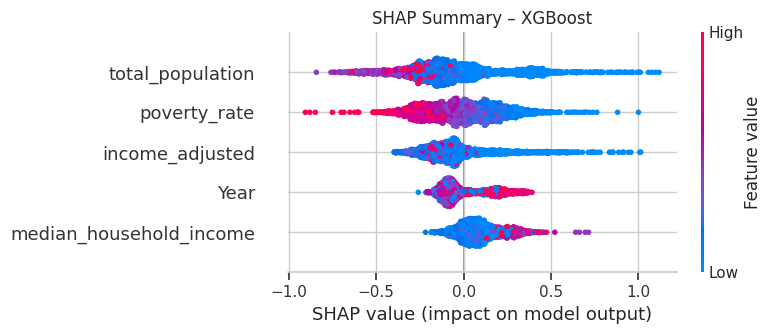

In [44]:
import os
import logging
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths
XGBOOST_RESULTS_DIR = "/content/results/xgboost_shap"
os.makedirs(XGBOOST_RESULTS_DIR, exist_ok=True)

LOG_FILE_XGB = os.path.join(XGBOOST_RESULTS_DIR, "xgboost_shap.log")
MODEL_PATH = os.path.join(XGBOOST_RESULTS_DIR, "xgboost_model.joblib")
METRICS_TXT = os.path.join(XGBOOST_RESULTS_DIR, "xgboost_metrics.txt")
SHAP_PNG = os.path.join(XGBOOST_RESULTS_DIR, "shap_summary_plot.png")

# Setup logger
xgb_logger = logging.getLogger("XGBoostAnalysis")
xgb_logger.setLevel(logging.INFO)
xgb_logger.propagate = False
if not xgb_logger.handlers:
    fh_xgb = logging.FileHandler(LOG_FILE_XGB, mode="w")
    sh_xgb = logging.StreamHandler()
    formatter_xgb = logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s")
    fh_xgb.setFormatter(formatter_xgb)
    sh_xgb.setFormatter(formatter_xgb)
    xgb_logger.addHandler(fh_xgb)
    xgb_logger.addHandler(sh_xgb)

# --- 1. Use existing enhanced df ---
if 'df' not in locals() or df is None:
    xgb_logger.error("Enhanced dataframe 'df' not found. Aborting.")
    raise SystemExit("Enhanced dataframe 'df' not found.")
else:
    xgb_logger.info("Using pre-loaded enhanced dataframe 'df'.")

# --- 2. Feature prep ---
if "ln_LoanAmountPerCapita" not in df.columns:
    xgb_logger.warning("'ln_LoanAmountPerCapita' not found. Creating it.")
    df["ln_LoanAmountPerCapita"] = np.log(df["LoanAmountPerCapita"].replace(0, np.nan))

df.replace([np.inf, -np.inf], np.nan, inplace=True)

features = ["Year", "total_population", "median_household_income", "poverty_rate", "income_adjusted"]
target = "ln_LoanAmountPerCapita"

df_xgb_ready = df.dropna(subset=features + [target])
xgb_logger.info(f"XGBoost dataset after NA drop → {df_xgb_ready.shape}")

if df_xgb_ready.empty:
    xgb_logger.error("No data left after cleaning.")
    raise SystemExit("No data left after cleaning.")

X = df_xgb_ready[features]
y = df_xgb_ready[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_logger.info(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# --- 3. Train model ---
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

try:
    xgb_model.fit(X_train, y_train)
    xgb_logger.info("Model trained successfully.")
except Exception as e:
    xgb_logger.error(f"Training failed: {e}")
    raise

# --- 4. Evaluate ---
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

with open(METRICS_TXT, "w") as f:
    f.write("XGBoost Evaluation Metrics\n")
    f.write("==========================\n")
    f.write(f"R²   : {r2:.4f}\n")
    f.write(f"MAE  : {mae:.4f}\n")
    f.write(f"MSE  : {mse:.4f}\n")
    f.write(f"RMSE : {rmse:.4f}\n")
xgb_logger.info(f"Metrics saved → {METRICS_TXT}")

# --- 5. SHAP ---
try:
    explainer = shap.Explainer(xgb_model)
    shap_values = explainer(X_test)
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
    plt.title("SHAP Summary – XGBoost")
    plt.tight_layout()
    plt.savefig(SHAP_PNG, bbox_inches="tight")
    xgb_logger.info(f"SHAP plot saved → {SHAP_PNG}")
except Exception as e:
    xgb_logger.error(f"SHAP failed: {e}")

# --- 6. Save model ---
try:
    joblib.dump(xgb_model, MODEL_PATH)
    xgb_logger.info(f"Model saved → {MODEL_PATH}")
except Exception as e:
    xgb_logger.error(f"Model save failed: {e}")

xgb_logger.info("🎉 XGBoost + SHAP workflow finished.")


In [56]:
!ls -l  # List files with details

total 13224
-rw-r--r-- 1 root root  483863 May  1 23:08 acs_b17001_poverty_processed.parquet
-rw-r--r-- 1 root root  305322 May  1 23:08 acs_dp05_population_processed.parquet
-rw-r--r-- 1 root root  300333 May  1 23:08 acs_s1901_income_processed.parquet
-rw-r--r-- 1 root root 1696078 May  2 00:04 correlation_analysis_data.parquet
-rw-r--r-- 1 root root    1237 May  2 00:05 correlation_changes_matrix.csv
-rw-r--r-- 1 root root    1145 May  2 00:05 correlation_matrix.csv
-rw-r--r-- 1 root root     204 May  1 23:08 cpi_u_annual_avg_2010_2023.csv
-rw-r--r-- 1 root root 1694334 May  2 00:04 enhanced_panel_data.parquet
-rw-r--r-- 1 root root   79365 May  1 23:08 fips_lookup.csv
-rw-r--r-- 1 root root 1336916 May  2 00:00 merged_acs_data.parquet
drwxr-xr-x 5 root root    4096 May  1 22:55 results
drwxr-xr-x 1 root root    4096 Apr 30 13:37 sample_data
-rw-r--r-- 1 root root 7600721 May  1 23:08 sba_504_raw_concatenated.parquet
-rw-r--r-- 1 root root     811 May  2 00:05 summary_statistics.csv

In [57]:
# Create a zip archive containing all files/folders
!zip -r full_data.zip *

# Download the zip
from google.colab import files
files.download('full_data.zip')

  adding: acs_b17001_poverty_processed.parquet (deflated 10%)
  adding: acs_dp05_population_processed.parquet (deflated 19%)
  adding: acs_s1901_income_processed.parquet (deflated 25%)
  adding: correlation_analysis_data.parquet (deflated 12%)
  adding: correlation_changes_matrix.csv (deflated 64%)
  adding: correlation_matrix.csv (deflated 63%)
  adding: cpi_u_annual_avg_2010_2023.csv (deflated 35%)
  adding: enhanced_panel_data.parquet (deflated 12%)
  adding: fips_lookup.csv (deflated 73%)
  adding: merged_acs_data.parquet (deflated 13%)
  adding: results/ (stored 0%)
  adding: results/panel_regression/ (stored 0%)
  adding: results/panel_regression/vif_results.txt (deflated 29%)
  adding: results/panel_regression/panel_regression.log (deflated 56%)
  adding: results/panel_regression/panel_regression_results.txt (deflated 71%)
  adding: results/xgboost_shap/ (stored 0%)
  adding: results/xgboost_shap/shap_summary_plot.png (deflated 4%)
  adding: results/xgboost_shap/xgboost_shap.log

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>